# Cloud-Native Access and Processing of Earth Observation Data
## 1. Cloud-native geospatial formats
Traditional geospatial workflows assume files are downloaded first, then processed locally. Cloud-native workflows invert this: data stays in cloud object storage, and analysis reads only the required pieces remotely.

| **Category**             | **Traditional Geospatial Formats**                   | **Cloud-Native Geospatial Formats**                      |
|--------------------------|------------------------------------------------------|----------------------------------------------------------|
| **Raster Data**          | GeoTIFF, IMG, HDF, NetCDF                            | Cloud Optimized GeoTIFF (COG), Zarr                      |
| **Vector Data**          | Shapefile, GeoJSON, KML                              | FlatGeobuf, Parquet (with GeoParquet), GeoArrow         |
| **Storage Requirements** | Typically stored locally                             | Optimized for cloud object storage (e.g., S3)            |
| **Access Pattern**       | Requires full download before access                 | Supports partial reads and streaming access              |
| **Metadata Handling**    | Embedded or separate sidecar files                   | Designed for embedded metadata and efficient discovery   |
| **Performance**          | Slower in distributed or remote environments         | Tuned for high-performance access in cloud workflows     |
| **Compatibility**        | Widely supported in legacy desktop tools             | Increasing support in modern cloud-based tools           |
| **Scalability**          | Limited by local machine capabilities                | Scalable with cloud compute and distributed frameworks   |
| **Examples of Usage**    | QGIS, ArcGIS Desktop                                 | STAC, Dask, Xarray, Rasterio, GeoPandas (cloud configs)  |

Cloud-native formats are designed for:

- chunking/tiling,
- internal indexing,
- HTTP range requests,
- parallel access.

So instead of downloading a full multi-GB scene, users can request only a small spatial window, selected bands, or specific time steps.

## 2. Why cloud-native formats matter
Cloud-native formats are important because they improve all major aspects of EO analytics:

- **Efficiency**: read only the needed spatial/temporal chunks.
- **Performance**: reduce I/O and improve parallel computation.
- **Cost control**: lower data transfer and avoid unnecessary copies.
- **Scalability**: support workflows from laptops to distributed cloud clusters.
- **Interoperability**: integrate well with modern geospatial tools and APIs.

In short, they make large-scale Earth Observation analysis practical, faster, and more reproducible.

## 3. Where data is hosted
Cloud-native geospatial datasets are typically stored in **object storage**, such as:

- AWS S3
- Azure Blob Storage
- Google Cloud Storage
- EO platform object stores and open data hubs

Object storage is preferred because it is durable, elastic, and directly accessible through standard web protocols (`https://`, `s3://`, etc.).

## 4. STAC: discovery and access layer
**STAC (SpatioTemporal Asset Catalog)** is an open standard for organizing and exposing geospatial data metadata in a consistent, machine-readable way.

Core STAC entities:

- **Catalog**: top-level grouping and navigation.
- **Collection**: a dataset family with shared metadata (e.g., Sentinel-2 L2A).
- **Item**: one spatiotemporal observation (e.g., one scene at one date/time).
- **Asset**: actual files linked from an Item (COG bands, thumbnails, metadata, masks, etc.).
![STAC hierarchy diagram](https://github.com/WinterSchool2026/zh04-cloud-native-eo-stac-xarray-dask/blob/main/assets/stac_catalog_example.png)

STAC does not replace data formats. Instead, it provides a common way to describe, find, and access assets across providers.

## 5. How STAC connects the dots
The key idea is the separation of concerns:

- **Cloud-native formats (COG, Zarr, GeoParquet)** optimize physical storage and remote reading.
- **STAC** optimizes discovery, metadata consistency, and cross-platform interoperability.
![STAC and formats diagram](https://github.com/WinterSchool2026/zh04-cloud-native-eo-stac-xarray-dask/blob/main/assets/stac_cloud_native.png)

A typical EO workflow becomes:

1. Query STAC using area, time range, and quality filters.
2. Receive matching Items and Asset URLs.
3. Read only needed chunks/windows from cloud-native assets.
4. Process results in scalable tools.
5. Publish outputs and metadata back into the ecosystem.

This is why STAC plus cloud-native formats has become a foundational pattern for operational geospatial data systems.
![STAC workflow diagram](https://github.com/WinterSchool2026/zh04-cloud-native-eo-stac-xarray-dask/blob/main/assets/stac_search_process_workflow.png)

## 6. Xarray and STAC
![xarray](https://github.com/WinterSchool2026/zh04-cloud-native-eo-stac-xarray-dask/blob/main/assets/xarray.png)

Xarray is a powerful Python library for working with multi-dimensional arrays, particularly useful for geospatial data. It can read from cloud-native formats like Zarr and COG, making it a great tool for working with STAC-referenced datasets.
- **DataArray**: a single multi-dimensional array with metadata. Similar to numpy ndarray but with labeled dimensions and coordinates.
- **Dataset**: a collection of DataArrays that share dimensions and coordinates. Similar to a dictionary of DataArrays.
- **Coordinates**: metadata that describes the dimensions of the data (e.g., time, latitude, longitude).
- **Attributes**: metadata that describes the data itself (e.g., units, description).
- **Indexing and slicing**: xarray allows for powerful indexing and slicing based on coordinates, making it easy to select specific spatial or temporal subsets of the data.
- **Lazy loading**: when reading from cloud-native formats, xarray can load data lazily, meaning it only reads the necessary chunks into memory when needed.
- **Integration with Dask**: xarray can integrate with Dask for parallel and distributed computing, which is essential for working with large geospatial datasets in the cloud.
- **Visualization**: xarray has built-in support for visualizing data using libraries like Matplotlib and Seaborn, making it easier to explore and analyze geospatial data.
## 7. Dask and STAC
![Dask](https://raw.githubusercontent.com/WinterSchool2026/zh04-cloud-native-eo-stac-xarray-dask/90fd812515eb0367c4b8c31fea9e6c66ddd8a468/assets/dask.svg)

Dask is a flexible parallel computing library for Python that can scale from a single machine to a cluster. It is particularly useful for working with large geospatial datasets referenced by STAC, as it allows for efficient processing without loading everything into memory at once.
- **Dask Arrays**: Dask provides a parallel version of NumPy arrays, allowing for out-of-core computation on large datasets.
- **Dask DataFrames**: Dask also provides a parallel version of Pandas DataFrames, which can be useful for working with tabular geospatial data.
- **Dask Delayed**: This allows you to build complex workflows by delaying the execution of functions until necessary, which can help manage dependencies and optimize execution.
- **Dask Futures**: This allows for asynchronous execution of tasks, which can be useful for handling long-running computations on large datasets.
- **Integration with Xarray**: Dask can be used in conjunction with Xarray to enable parallel processing of multi-dimensional geospatial data, making it easier to work with large datasets in the cloud.


# Valencia Flood: Unsupervised Change Detection with Sentinel-2 and Sentinel-1

This notebook builds a workflow around flood change detection in Valencia (29-30 October 2023) using both Sentinel-2 (optical) and Sentinel-1 (radar) data. The goal is to perform unsupervised change detection for both sensors, using spectral/index change clustering for Sentinel-2 and backscatter change clustering for Sentinel-1.

## Goal
Run **unsupervised change detection** for both:
- **Sentinel-2 (optical)**: spectral/index change clustering
- **Sentinel-1 RTC (radar)**: backscatter change clustering

In [13]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib as mpl


import xarray as xr
from dask.distributed import Client
import pystac_client
import stackstac
import planetary_computer
from rasterio.enums import Resampling

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import folium


In [ ]:
## Initiate local Dask client
client = Client(memory_limit="2GB")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 7.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:51685,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 7.45 GiB
Comm: tcp://127.0.0.1:51698,Total threads: 2
Dashboard: http://127.0.0.1:51703/status,Memory: 1.86 GiB
Nanny: tcp://127.0.0.1:51688,


2026-03-13 16:18:46,521 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0) nanmedian(..., ...)>
new run_spec: Alias(('nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0)->('rechunk-merge-nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0))
old token: '9ac52846f56601f619233bebd18b29c8'
new token: ('Alias', ('nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0), ('rechunk-merge-nanmedian-252f981c4e5190d80f741a739798aa39', 1, 0, 0))
old

## 1) Valencia point, dates, APIs, and bounding box

- `LAT, LON = 39.3336, -0.3545`
- `START_DATE_S2 = 2024-10-01`
- `END_DATE_S2 = 2024-12-01`
- `AWS_STAC_API = https://earth-search.aws.element84.com/v1`
- `COLLECTION_S2 = sentinel-2-l2a`
- `BEFORE_DATE_S2 = 2024-10-01`
- `AFTER_DATE_S2 = 2024-11-10`
- `PLANETARY_STAC_API = https://planetarycomputer.microsoft.com/api/stac/v1`
- `COLLECTION_S1 = sentinel-1-rtc`
- `START_DATE_S1 = 2024-10-01`
- `END_DATE_S1 = 2024-12-01`
- `BEFORE_DATE_S1 = 2024-10-07`
- `AFTER_DATE_S1 = 2024-11-12`


In [3]:
LAT, LON = 39.3336, -0.3545

START_DATE_S2 = "2024-10-01"
END_DATE_S2 = "2024-12-01"
AWS_STAC_API = "https://earth-search.aws.element84.com/v1"
COLLECTION_S2 = "sentinel-2-l2a"
BEFORE_DATE_S2 = "2024-10-01"
AFTER_DATE_S2 = "2024-11-10"

PLANETARY_STAC_API = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION_S1 = "sentinel-1-rtc"
START_DATE_S1 = "2024-10-01"
END_DATE_S1 = "2024-12-01"
BEFORE_DATE_S1 = "2024-10-07"
AFTER_DATE_S1 = "2024-11-12"

# Bounding box around the point (adjust if you want a wider/narrower AOI)
HALF_SIZE_DEG = 0.06  # ~6-7 km in lat; lon distance depends on latitude
BBOX = [LON - HALF_SIZE_DEG, LAT - HALF_SIZE_DEG, LON + HALF_SIZE_DEG, LAT + HALF_SIZE_DEG]

TARGET_EPSG = 32630  # Valencia area ~ UTM 30N

# Runtime knobs
S2_MAX_ITEMS_PER_WINDOW = 10
S1_MAX_ITEMS_PER_WINDOW = 12
RESOLUTION_M = 20

# Centered windows for before/after composites
S2_WINDOW_DAYS = 10
S1_WINDOW_DAYS = 10

print("Point (lat, lon):", (LAT, LON))
print("BBOX [min_lon, min_lat, max_lon, max_lat]:", BBOX)
print("Target CRS EPSG:", TARGET_EPSG)
print("S2 API:", AWS_STAC_API)
print("S1 API:", PLANETARY_STAC_API)


Point (lat, lon): (39.3336, -0.3545)
BBOX [min_lon, min_lat, max_lon, max_lat]: [-0.4145, 39.273599999999995, -0.2945, 39.3936]
Target CRS EPSG: 32630
S2 API: https://earth-search.aws.element84.com/v1
S1 API: https://planetarycomputer.microsoft.com/api/stac/v1


In [4]:
def centered_window(date_str, half_days):
    d = datetime.fromisoformat(date_str)
    start = (d - timedelta(days=half_days)).date().isoformat()
    end = (d + timedelta(days=half_days)).date().isoformat()
    return f"{start}/{end}"

S2_BEFORE_WINDOW = centered_window(BEFORE_DATE_S2, S2_WINDOW_DAYS)
S2_AFTER_WINDOW = centered_window(AFTER_DATE_S2, S2_WINDOW_DAYS)
S1_BEFORE_WINDOW = centered_window(BEFORE_DATE_S1, S1_WINDOW_DAYS)
S1_AFTER_WINDOW = centered_window(AFTER_DATE_S1, S1_WINDOW_DAYS)
S2_FULL_WINDOW = f"{START_DATE_S2}/{END_DATE_S2}"
S1_FULL_WINDOW = f"{START_DATE_S1}/{END_DATE_S1}"

print("S2 before window:", S2_BEFORE_WINDOW)
print("S2 after  window:", S2_AFTER_WINDOW)
print("S2 full   window:", S2_FULL_WINDOW)
print("S1 before window:", S1_BEFORE_WINDOW)
print("S1 after  window:", S1_AFTER_WINDOW)
print("S1 full   window:", S1_FULL_WINDOW)


S2 before window: 2024-09-21/2024-10-11
S2 after  window: 2024-10-31/2024-11-20
S2 full   window: 2024-10-01/2024-12-01
S1 before window: 2024-09-27/2024-10-17
S1 after  window: 2024-11-02/2024-11-22
S1 full   window: 2024-10-01/2024-12-01


In [5]:
# Center map on the provided point
m = folium.Map(location=[LAT, LON], tiles="Cartodb Positron", zoom_start=13)

# Point marker
folium.Marker(
    location=[LAT, LON],
    popup=f"Valencia point\n({LAT:.4f}, {LON:.4f})",
    tooltip="Valencia point",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(m)

# Bounding box polygon (folium uses [lat, lon])
bbox_coords = [
    [BBOX[1], BBOX[0]],  # min_lat, min_lon
    [BBOX[1], BBOX[2]],  # min_lat, max_lon
    [BBOX[3], BBOX[2]],  # max_lat, max_lon
    [BBOX[3], BBOX[0]],  # max_lat, min_lon
    [BBOX[1], BBOX[0]],  # close polygon
]

folium.PolyLine(
    locations=bbox_coords,
    color="blue",
    weight=3,
    opacity=0.9,
    tooltip="AOI bounding box",
).add_to(m)

# Optional semi-transparent fill
folium.Polygon(
    locations=bbox_coords[:-1],
    color="blue",
    weight=2,
    fill=True,
    fill_opacity=0.12,
).add_to(m)

# Fit map to AOI
m.fit_bounds([[BBOX[1], BBOX[0]], [BBOX[3], BBOX[2]]])

m


## 2) Shared helpers

These helpers keep the S2 and S1 workflows consistent and avoid common `xarray` merge issues from `stackstac` metadata coordinates.


In [6]:
def clean_da(da):
    # Drop scalar metadata coordinates (band, description, title, etc.) before merging into Dataset
    da = da.reset_coords(drop=True)
    da.attrs = {}
    return da.astype("float32")


def maybe_to_reflectance(arr):
    # Sentinel-2 can be in DN-like scale (~0..10000). Convert to reflectance if needed.
    vmax = float(arr.max().compute())
    if vmax > 2:
        return arr / 10000.0
    return arr


def quick_rgb_display(rgb, ax, title):
    # rgb dims expected: (band, y, x) with bands [red, green, blue]
    p2 = rgb.quantile(0.02, dim=("x", "y"))
    p98 = rgb.quantile(0.98, dim=("x", "y"))
    rgb_disp = ((rgb - p2) / (p98 - p2)).clip(0, 1) ** (1 / 2.2)
    rgb_disp.plot.imshow(ax=ax, rgb="band")
    ax.set_title(title)
    ax.axis("off")


def query_items(api_url, collection, bbox, dt_range, max_items=10, query=None, pc_sign=False):
    modifier = planetary_computer.sign_inplace if pc_sign else None
    catalog = pystac_client.Client.open(api_url, modifier=modifier)
    search = catalog.search(
        collections=[collection],
        bbox=bbox,
        datetime=dt_range,
        max_items=max_items,
        query=query,
    )
    items = list(search.item_collection())
    if pc_sign:
        # Defensive re-sign in case downstream stackstac reads original hrefs.
        items = [planetary_computer.sign(item) for item in items]
    return items


def items_table(items, extra_cols=None):
    extra_cols = extra_cols or []
    data = {
        "id": [i.id for i in items],
        "datetime": [i.datetime for i in items],
    }
    for c in extra_cols:
        data[c] = [i.properties.get(c, np.nan) for i in items]
    return pd.DataFrame(data).sort_values("datetime")


def build_change_cluster_map(feature_ds, n_clusters=5, sample_n=25000, random_state=42):
    df = feature_ds.to_dataframe().dropna().reset_index()
    feat_cols = [c for c in feature_ds.data_vars]
    if len(df) == 0:
        raise RuntimeError("No valid pixels after dropna() for clustering")

    train_df = df.sample(min(sample_n, len(df)), random_state=random_state)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feat_cols])

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    km.fit(X_train)

    X_all = scaler.transform(df[feat_cols])
    df["cluster"] = km.predict(X_all)

    # Cluster change strength = centroid norm in standardized feature space
    centers = pd.DataFrame(km.cluster_centers_, columns=feat_cols)
    centers["change_strength"] = np.sqrt((centers[feat_cols] ** 2).sum(axis=1))
    strength_map = centers["change_strength"].to_dict()
    df["cluster_change_strength"] = df["cluster"].map(strength_map)

    # Optional 2D PCA embedding for interpretation
    pca = PCA(n_components=2, random_state=random_state)
    X_train_pca = pca.fit_transform(X_train)
    pca_df = pd.DataFrame(X_train_pca, columns=["pc1", "pc2"])
    pca_df["cluster"] = km.predict(X_train)

    cluster_map = df.set_index(["y", "x"])["cluster"].to_xarray()
    strength_raster = df.set_index(["y", "x"])["cluster_change_strength"].to_xarray()

    return {
        "df": df,
        "feature_cols": feat_cols,
        "kmeans": km,
        "centers": centers.sort_values("change_strength", ascending=False),
        "cluster_map": cluster_map,
        "strength_raster": strength_raster,
        "pca_df": pca_df,
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }


## 3) Sentinel-2 (optical): unsupervised spectral/index change detection

### Idea
Create **before** and **after** cloud-masked composites and cluster pixels by their spectral/index changes.

This reveals **different change modes** (not only flood/non-flood), such as:
- increased wetness / inundation signals
- vegetation stress/recovery
- bare soil / sediment changes
- stable background


In [7]:
S2_COLLECTION = COLLECTION_S2
S2_BANDS = ["blue", "green", "red", "nir", "swir16", "scl"]

s2_before_items = query_items(
    AWS_STAC_API,
    S2_COLLECTION,
    BBOX,
    S2_BEFORE_WINDOW,
    max_items=S2_MAX_ITEMS_PER_WINDOW,
    query={"eo:cloud_cover": {"lt": 50}},
)
s2_after_items = query_items(
    AWS_STAC_API,
    S2_COLLECTION,
    BBOX,
    S2_AFTER_WINDOW,
    max_items=S2_MAX_ITEMS_PER_WINDOW,
    query={"eo:cloud_cover": {"lt": 50}},
)

print(f"S2 before items: {len(s2_before_items)}")
print(f"S2 after  items: {len(s2_after_items)}")
if len(s2_before_items) == 0 or len(s2_after_items) == 0:
    raise RuntimeError("Need S2 items in both windows. Widen S2_WINDOW_DAYS or cloud filter.")

display(items_table(s2_before_items, ["eo:cloud_cover"]))
display(items_table(s2_after_items, ["eo:cloud_cover"]))


S2 before items: 4
S2 after  items: 5


,id,datetime,eo:cloud_cover
3,S2A_31SBD_20240926_0_L2A,2024-09-26 11:00:16.116000+00:00,0.009257
2,S2A_30SYJ_20240926_0_L2A,2024-09-26 11:00:16.805000+00:00,0.150484
1,S2B_31SBD_20241001_0_L2A,2024-10-01 11:00:15.349000+00:00,9.907760
0,S2B_30SYJ_20241001_0_L2A,2024-10-01 11:00:16.036000+00:00,11.716232


,id,datetime,eo:cloud_cover
4,S2B_31SBD_20241110_0_L2A,2024-11-10 11:00:08.754000+00:00,36.981049
3,S2B_30SYJ_20241110_0_L2A,2024-11-10 11:00:09.426000+00:00,34.087646
2,S2A_31SBD_20241115_0_L2A,2024-11-15 11:00:13.673000+00:00,22.916301
1,S2A_30SYJ_20241115_0_L2A,2024-11-15 11:00:14.353000+00:00,36.760402
0,S2B_30SYJ_20241120_0_L2A,2024-11-20 11:00:14.498000+00:00,45.419726


In [8]:
s2_before = stackstac.stack(
    s2_before_items,
    assets=S2_BANDS,
    epsg=TARGET_EPSG,
    bounds_latlon=BBOX,
    resolution=RESOLUTION_M,
    resampling=Resampling.bilinear,
    chunksize=(1, 1, 1024, 1024),
    dtype="float",
    errors_as_nodata=(Exception,),
)

s2_after = stackstac.stack(
    s2_after_items,
    assets=S2_BANDS,
    epsg=TARGET_EPSG,
    bounds_latlon=BBOX,
    resolution=RESOLUTION_M,
    resampling=Resampling.bilinear,
    chunksize=(1, 1, 1024, 1024),
    dtype="float",
    errors_as_nodata=(Exception,),
)

s2_before, s2_after


(<xarray.DataArray 'stackstac-40c2432a683e31aaa012a6c154f45b1b' (time: 4,
                                                                 band: 6,
                                                                 y: 682, x: 538)> Size: 70MB
 dask.array<fetch_raster_window, shape=(4, 6, 682, 538), dtype=float64, chunksize=(1, 1, 682, 538), chunktype=numpy.ndarray>
 Coordinates: (12/51)
   * time                                     (time) datetime64[ns] 32B 2024-0...
     id                                       (time) <U24 384B 'S2A_31SBD_2024...
   * band                                     (band) <U6 144B 'blue' ... 'scl'
   * x                                        (x) float64 4kB 7.226e+05 ... 7....
   * y                                        (y) float64 5kB 4.364e+06 ... 4....
     mgrs:utm_zone                            (time) int64 32B 31 30 31 30
     ...                                       ...
     raster:bands                             (band) object 48B {'nodata': 0, .

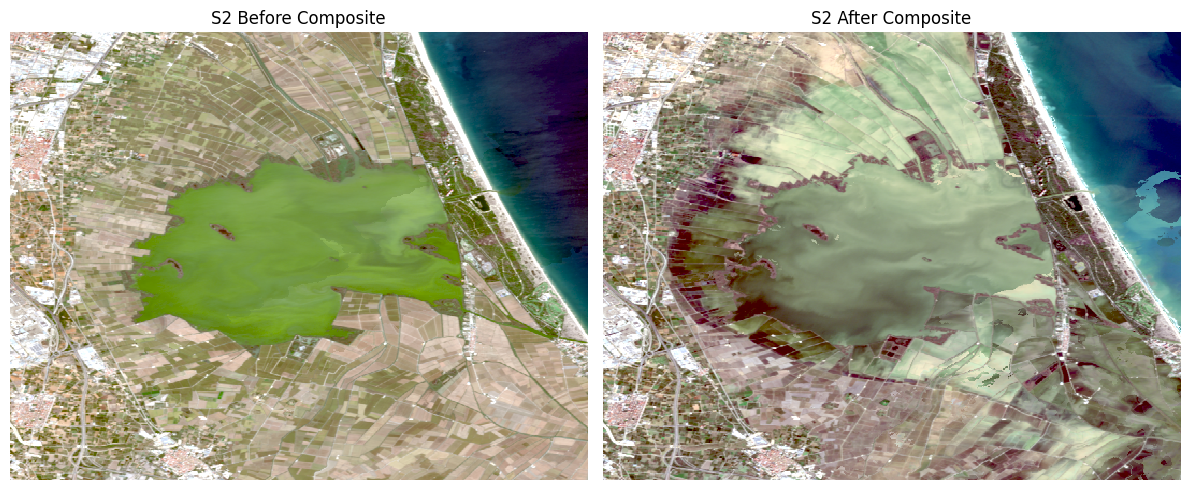

In [9]:
# Cloud mask with SCL (Dask-friendly: use .isin, not apply_ufunc(np.isin,...))
bad_scl = [3, 8, 9, 10, 11]  # shadow, clouds, cirrus, snow/ice

scl_before = s2_before.sel(band="scl")
scl_after = s2_after.sel(band="scl")

clear_before = ~scl_before.isin(bad_scl)
clear_after = ~scl_after.isin(bad_scl)

opt_before = s2_before.sel(band=["blue", "green", "red", "nir", "swir16"]).where(clear_before)
opt_after = s2_after.sel(band=["blue", "green", "red", "nir", "swir16"]).where(clear_after)

opt_before = maybe_to_reflectance(opt_before)
opt_after = maybe_to_reflectance(opt_after)

# Robust composites for before/after windows
s2_before_med = opt_before.median(dim="time", skipna=True)
s2_after_med = opt_after.median(dim="time", skipna=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
quick_rgb_display(s2_before_med.sel(band=["red", "green", "blue"]), axes[0], "S2 Before Composite")
quick_rgb_display(s2_after_med.sel(band=["red", "green", "blue"]), axes[1], "S2 After Composite")
plt.tight_layout()
plt.show()


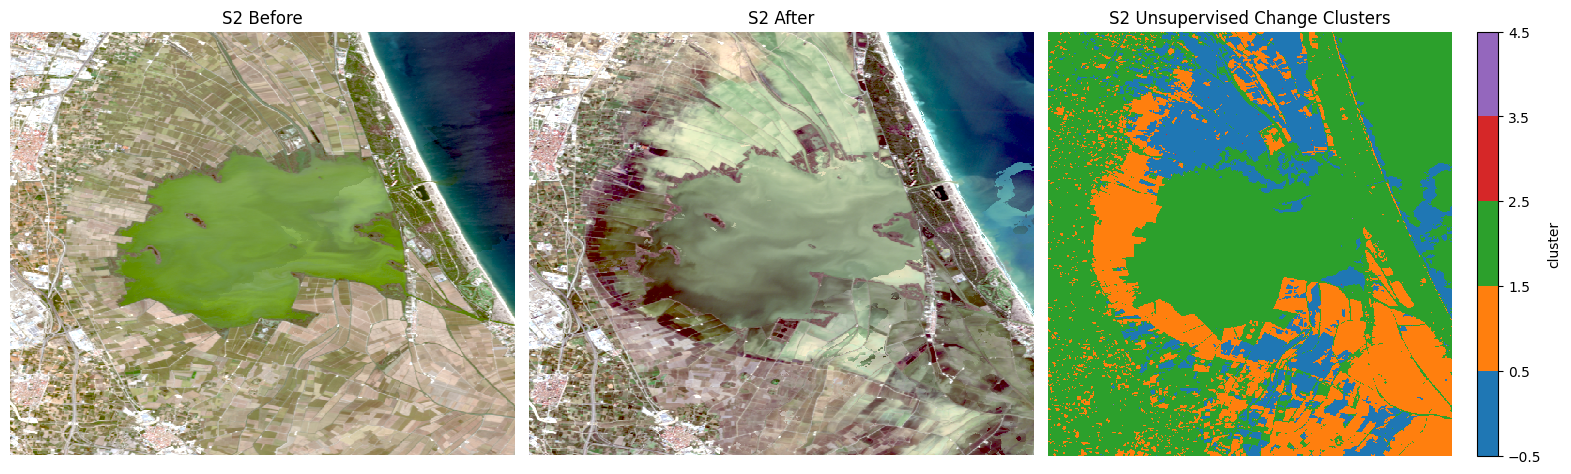

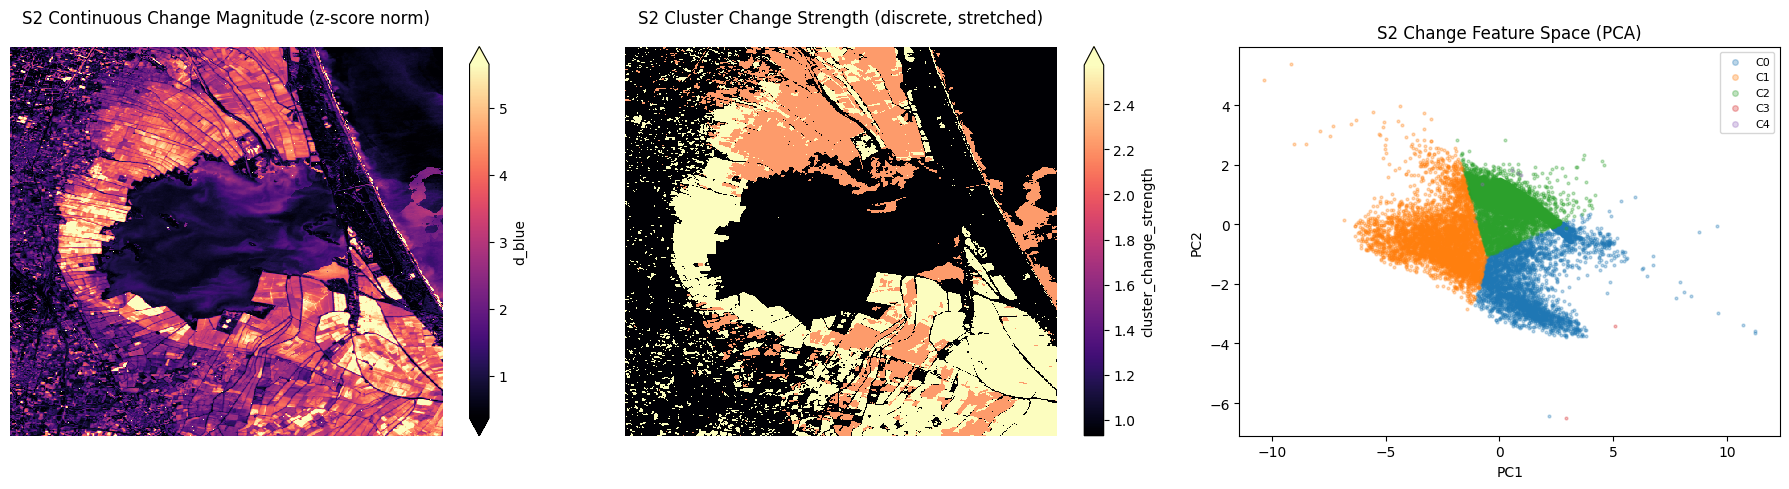

,d_blue,d_green,d_red,d_nir,d_swir16,d_ndvi,d_mndwi,d_nbr,change_strength
3,1.920,1.900,1.869,-0.011,-0.013,-89.543999,0.012000,-0.006,89.603996
4,-0.070,-0.173,-0.055,0.102,0.353,0.009000,-59.900002,-0.006,59.901001
1,-1.144,-1.032,-1.248,-1.091,-1.226,0.019000,0.013000,-0.005,2.574000
0,1.115,1.394,1.097,-0.611,-0.454,0.006000,0.016000,0.041,2.229000
2,0.125,-0.007,0.173,0.636,0.643,0.006000,0.015000,-0.011,0.930000


In [14]:
# Build change features (not only water): spectral deltas + index deltas
b_blue = clean_da(s2_before_med.sel(band="blue", drop=True))
b_green = clean_da(s2_before_med.sel(band="green", drop=True))
b_red = clean_da(s2_before_med.sel(band="red", drop=True))
b_nir = clean_da(s2_before_med.sel(band="nir", drop=True))
b_swir = clean_da(s2_before_med.sel(band="swir16", drop=True))

a_blue = clean_da(s2_after_med.sel(band="blue", drop=True))
a_green = clean_da(s2_after_med.sel(band="green", drop=True))
a_red = clean_da(s2_after_med.sel(band="red", drop=True))
a_nir = clean_da(s2_after_med.sel(band="nir", drop=True))
a_swir = clean_da(s2_after_med.sel(band="swir16", drop=True))

eps = 1e-6
b_ndvi = clean_da((b_nir - b_red) / (b_nir + b_red + eps))
a_ndvi = clean_da((a_nir - a_red) / (a_nir + a_red + eps))

b_mndwi = clean_da((b_green - b_swir) / (b_green + b_swir + eps))
a_mndwi = clean_da((a_green - a_swir) / (a_green + a_swir + eps))

b_nbr = clean_da((b_nir - b_swir) / (b_nir + b_swir + eps))
a_nbr = clean_da((a_nir - a_swir) / (a_nir + a_swir + eps))

s2_change_feats = xr.Dataset({
    "d_blue": clean_da(a_blue - b_blue),
    "d_green": clean_da(a_green - b_green),
    "d_red": clean_da(a_red - b_red),
    "d_nir": clean_da(a_nir - b_nir),
    "d_swir16": clean_da(a_swir - b_swir),
    "d_ndvi": clean_da(a_ndvi - b_ndvi),
    "d_mndwi": clean_da(a_mndwi - b_mndwi),
    "d_nbr": clean_da(a_nbr - b_nbr),
})

N_CLUSTERS = 5
# Unsupervised clustering of change signatures
s2_clust = build_change_cluster_map(s2_change_feats, n_clusters=N_CLUSTERS, sample_n=20000)

# Continuous per-pixel change magnitude (fixes the "all black" cluster-strength map issue)
# We z-score each feature by its spatial std, then compute Euclidean norm across features.
feat_stack = xr.concat([clean_da(s2_change_feats[v]) for v in s2_change_feats.data_vars], dim="feature")
feat_stack = feat_stack.assign_coords(feature=list(s2_change_feats.data_vars))

feat_sigma = feat_stack.std(dim=("x", "y"), skipna=True)
feat_z = feat_stack / (feat_sigma + 1e-6)
s2_change_mag = np.sqrt((feat_z ** 2).sum(dim="feature")).compute()

# Also keep a stretched version of the cluster-based strength map (discrete values)
s2_cluster_strength = s2_clust["strength_raster"].compute()

# Visualization
tab10 = plt.get_cmap("tab10")
cmap = mpl.colors.ListedColormap([tab10(i % 10) for i in range(N_CLUSTERS)])
bounds = np.r_[np.arange(N_CLUSTERS) - 0.5, N_CLUSTERS - 0.5]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
quick_rgb_display(s2_before_med.sel(band=["red", "green", "blue"]), axes[0], "S2 Before")
quick_rgb_display(s2_after_med.sel(band=["red", "green", "blue"]), axes[1], "S2 After")
s2_clust["cluster_map"].plot(ax=axes[2], cmap=cmap, norm=norm)
axes[2].set_title("S2 Unsupervised Change Clusters")
axes[2].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Continuous magnitude: main change-intensity visualization
s2_change_mag.plot(ax=axes[0], cmap="magma", robust=True)
axes[0].set_title("S2 Continuous Change Magnitude (z-score norm)")
axes[0].axis("off")

# Cluster strength kept for interpretation (discrete, stretched)
s2_cluster_strength.plot(ax=axes[1], cmap="magma", robust=True)
axes[1].set_title("S2 Cluster Change Strength (discrete, stretched)")
axes[1].axis("off")

# PCA feature-space view for interpreting clusters
pca_df = s2_clust["pca_df"]
for c in sorted(pca_df["cluster"].unique()):
    d = pca_df[pca_df["cluster"] == c]
    axes[2].scatter(d["pc1"], d["pc2"], s=4, alpha=0.3,color=cmap(norm(c)), label=f"C{c}")
axes[2].set_title("S2 Change Feature Space (PCA)")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

display(s2_clust["centers"].round(3))


### Reading the S2 result

Clusters with large positive `d_mndwi` / negative `d_nir` / negative `d_ndvi` can indicate increased wetness or inundation,
but the key point is that **the algorithm discovers multiple change patterns**, not a single binary flood mask.


## 4) Sentinel-1 RTC (radar): unsupervised backscatter change detection

### Idea
Build before/after radar composites and cluster **change signatures** in VV/VH dB space.

This complements S2 because radar is often usable during/after cloudy periods.


In [1]:
#TODO: Query Sentinel-1 collection similar to what has been done for Sentinel-2, but using the PLANETARY_STAC_API and COLLECTION_S1, and adjusting the query parameters as needed (e.g., for polarization, orbit direction, etc.)

In [2]:
#TODO: Use stackstac to load S1 before/after composites, similar to S2, but with appropriate adjustments for S1 data structure and bands (e.g., VV, VH). Consider using median or mean composites.

In [3]:
#TODO: Build median composite images for S1 before/after, transform to dB scale, and compute simple change features like VV, VH, and VV-VH differences.

In [4]:
#TODO: Build xarray Dataset of S1 change features (dVV, dVH, dVV/VH ratio, mean VV, mean VH) for clustering. Apply the same build_change_cluster_map function to S1 change features to get unsupervised clusters and change strength.

## 5) Cross-sensor comparison (optional but useful)

Compare where S2 and S1 flag strong changes. Agreement increases confidence; disagreement is also informative
(e.g., cloud contamination in S2, moisture/roughness sensitivity in S1).


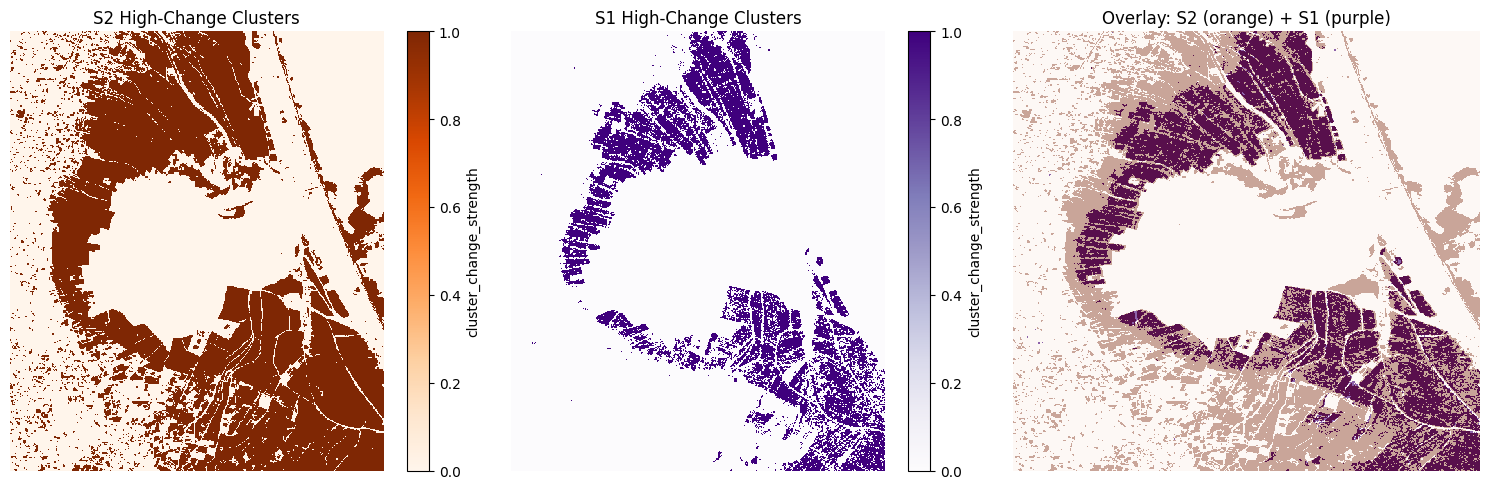

In [23]:
# Create quick binary "high change" masks from both sensors for visual comparison
s2_strength = s2_clust["strength_raster"]
s2_thr = float(s2_clust["df"]["cluster_change_strength"].quantile(0.76))
s2_high_change = (s2_strength >= s2_thr)

s1_strength = s1_clust["strength_raster"]
s1_thr = float(s1_clust["df"]["cluster_change_strength"].quantile(0.9))
s1_high_change = (s1_strength >= s1_thr)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
s2_high_change.plot(ax=axes[0], cmap="Oranges", vmin=0, vmax=1)
axes[0].set_title("S2 High-Change Clusters")
axes[0].axis("off")

s1_high_change.plot(ax=axes[1], cmap="Purples", vmin=0, vmax=1)
axes[1].set_title("S1 High-Change Clusters")
axes[1].axis("off")

# Overlay by plotting S2 first then S1 transparent where True
s2_high_change.plot(ax=axes[2], cmap="Oranges", add_colorbar=False, vmin=0, vmax=1)
s1_high_change.plot(ax=axes[2], cmap="Purples", add_colorbar=False, alpha=0.6, vmin=0, vmax=1)
axes[2].set_title("Overlay: S2 (orange) + S1 (purple)")
axes[2].axis("off")
plt.tight_layout()
plt.show()


### Good follow-ups
1. Increase/decrease `HALF_SIZE_DEG` to explore a larger area.
2. Change `n_clusters` to compare cluster stability.
3. Add weak labels later (e.g., hand-drawn polygons) to turn this into semi-supervised or supervised mapping.
